# Plantalyze model - Arquitectura 1 v1
Modelo de machine learning para detección de especies de plantas a partir de imágenes.

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import kagglehub

 # Hiperparámetros

In [24]:
IMG_WIDTH, IMG_HEIGHT = 128, 128
BATCH_SIZE = 128
LEARNING_RATE = 0.0001
EPOCHS = 100

### Importar dataset

In [25]:
path = kagglehub.dataset_download("marquis03/plants-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plants-classification' dataset.
Path to dataset files: /kaggle/input/plants-classification


Nota: Este dataset ya estaba separado con una distribución de **70/20/10**, 70% train, 20% test y 10% validation.

In [26]:
train_dir = path + "/train"
test_dir = path + "/test"
val_dir = path + "/val"

### Redimensionar todas las imágenes a 128 x 128
Sin data augmentation para el modelo.

Found 21000 images belonging to 30 classes.
Found 6000 images belonging to 30 classes.
Found 3000 images belonging to 30 classes.
(128, 128, 128, 3)


<Figure size 640x480 with 0 Axes>

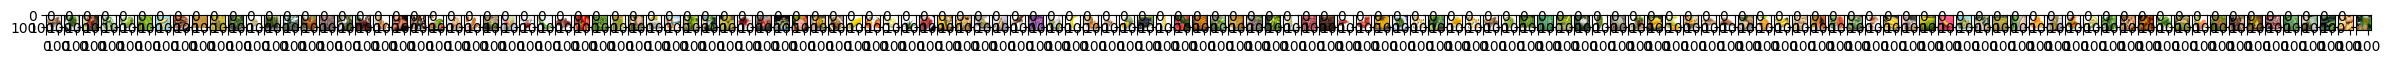

In [27]:
datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

val_generator = datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

images , labels = train_generator[0]

print(images.shape)

plt.figure()
f, axarr = plt.subplots(1, images.shape[0], figsize=(30, 4))

for i in range(images.shape[0]) :
  axarr[i].imshow(images[i])

In [28]:
from sklearn import metrics
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Input,
    Dropout
)

def get_model_compiled():
  model = Sequential()
  model.add(Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

  model.add(Conv2D(128, kernel_size=3, activation="relu", padding="same"))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  model.add(Conv2D(128, kernel_size=3, activation="relu", padding="same"))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  model.add(Conv2D(128, kernel_size=3, activation="relu", padding="same"))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  model.add(Conv2D(128, kernel_size=3, activation="relu", padding="same"))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  model.add(Conv2D(64, kernel_size=3, activation="relu", padding="same"))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  model.add(Conv2D(64, kernel_size=3, activation="relu", padding="same"))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  model.add(Conv2D(32, kernel_size=3, activation="relu", padding="same"))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  model.add(Dropout(0.5))
  model.add(Flatten())
  model.add(Dense(128, activation="relu"))
  model.add(Dense(30, activation="softmax"))

  model.compile(
      loss="categorical_crossentropy",
      metrics=["accuracy"],

  )

  return model

In [29]:
model = get_model_compiled()
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 128, 128, 128)  │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 2, 2, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 1, 1, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 1, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 30)             │         3,870 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 583,614 (2.23 MB)

 Trainable params: 583,614 (2.23 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping

from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Plantalyze

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Plantalyze


In [31]:
%ls

checkpoints/


In [32]:
current_directory = "/content/drive/MyDrive/Plantalyze"
checkpoint_path = current_directory + "/checkpoints/checkpoint_arq1_v2.weights.h5"
checkpoint = ModelCheckpoint(filepath=checkpoint_path,
                             save_freq= "epoch",
                             save_weights_only = True,
                             verbose = 1)
early_stop = EarlyStopping(monitor='val_loss', patience=5)

In [33]:
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[checkpoint, early_stop])

Epoch 1/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 781ms/step - accuracy: 0.0408 - loss: 3.3807
Epoch 1: saving model to /content/drive/MyDrive/Plantalyze/checkpoints/checkpoint_arq1_v2.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Plantalyze/checkpoints/checkpoint_arq1_v2.weights.h5
165/165 ━━━━━━━━━━━━━━━━━━━━ 169s 943ms/step - accuracy: 0.0487 - loss: 3.3452 - val_accuracy: 0.0563 - val_loss: 3.2749
Epoch 2/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.0601 - loss: 3.2674
Epoch 2: saving model to /content/drive/MyDrive/Plantalyze/checkpoints/checkpoint_arq1_v2.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/Plantalyze/checkpoints/checkpoint_arq1_v2.weights.h5
165/165 ━━━━━━━━━━━━━━━━━━━━ 64s 385ms/step - accuracy: 0.0598 - loss: 3.2516 - val_accuracy: 0.0617 - val_loss: 3.1734
Epoch 3/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.0693 - loss: 3.1821
Epoch 3: saving model to /content/drive/MyDrive/Plantalyze/checkpoin

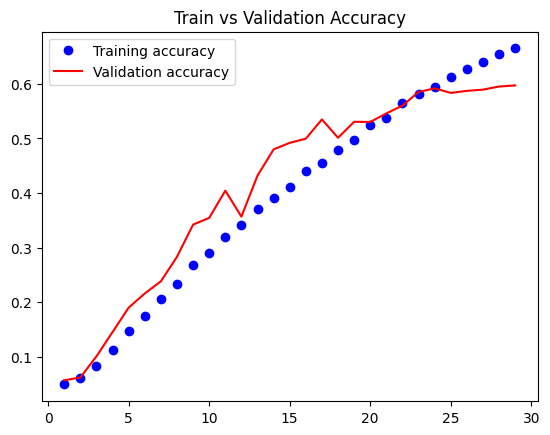

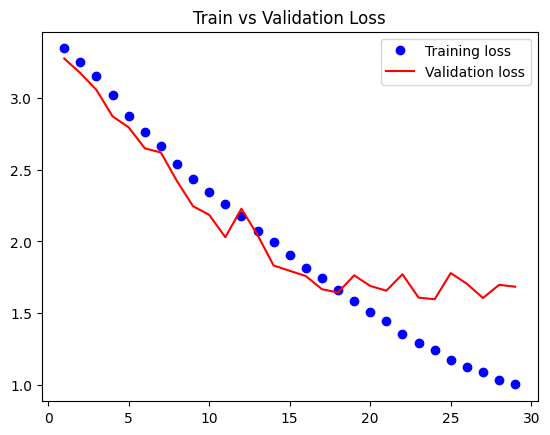

In [34]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.plot(epochs_range, acc, "bo", label="Training accuracy")
plt.plot(epochs_range, val_acc, "r", label="Validation accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()

plt.figure()

plt.plot(epochs_range, loss, "bo", label="Training loss")
plt.plot(epochs_range, val_loss, "r", label="Validation loss")
plt.title("Train vs Validation Loss")
plt.legend()

plt.show()

In [35]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc}")
print(f"Test loss: {test_loss}")

predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

47/47 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.5652 - loss: 1.9058
Test accuracy: 0.5651666522026062
Test loss: 1.905848503112793
47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 335ms/step


Classification Report:
               precision    recall  f1-score   support

     aloevera       0.64      0.69      0.67       200
       banana       0.67      0.23      0.34       200
      bilimbi       0.55      0.35      0.43       200
   cantaloupe       0.47      0.38      0.42       200
      cassava       0.49      0.73      0.59       200
      coconut       0.50      0.35      0.41       200
         corn       0.50      0.64      0.56       200
     cucumber       0.45      0.80      0.58       200
      curcuma       0.88      0.61      0.72       200
     eggplant       0.65      0.85      0.74       200
     galangal       0.43      0.78      0.55       200
       ginger       0.48      0.43      0.45       200
        guava       0.66      0.67      0.67       200
         kale       0.77      0.43      0.55       200
    longbeans       0.58      0.81      0.67       200
        mango       0.30      0.52      0.38       200
        melon       0.36      0.27      0

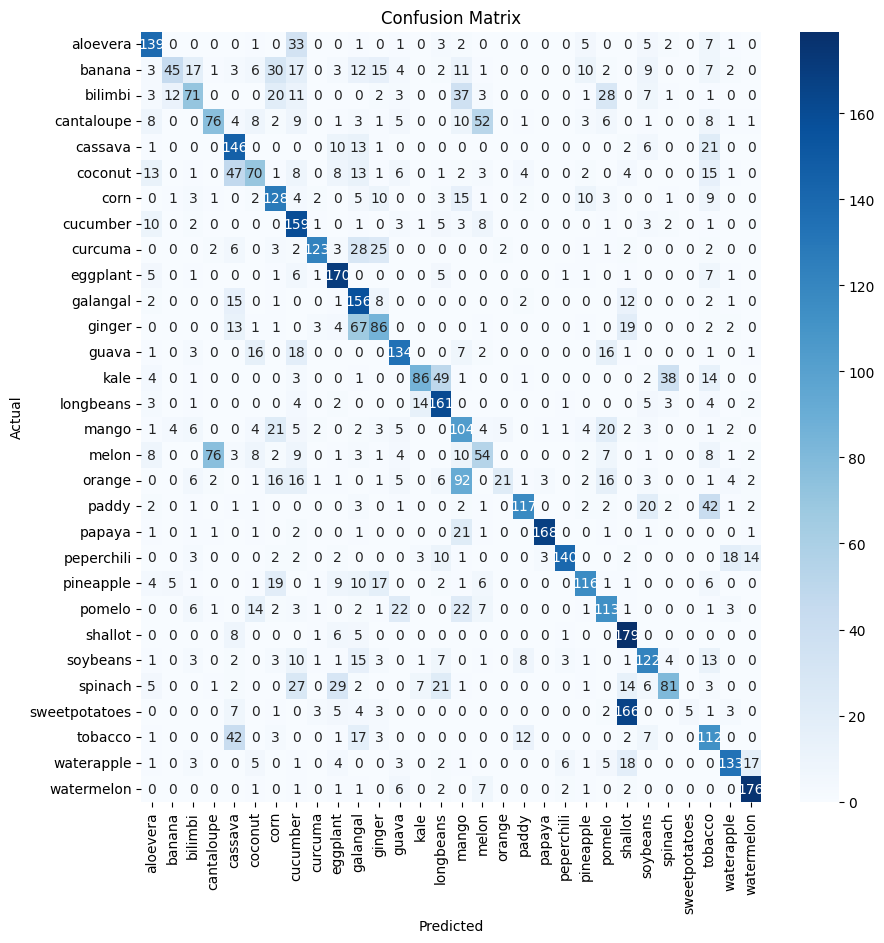

In [41]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

class_names = list(test_generator.class_indices.keys())

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
)


conf_matrix = confusion_matrix(y_true, y_pred)

print("Classification Report:")
print(report)

plt.figure(figsize=(10, 10))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [40]:
%cd checkpoints/
%ls

[Errno 2] No such file or directory: 'checkpoints/'
/content/drive/MyDrive/Plantalyze/checkpoints
checkpoint_arq2_v2.weights.h5  checkpoint_arq2.weights.h5


In [39]:
%rm -rf checkpoint_arq1_v2.weights.h5